# Statlig samferdselsfinansiering per landsdel 2014–2035

Analyse av datasett `Samferdselprosjekter_pr_landsdel_over_tid_public_-_Prosjekter_2014_2026pluss.csv`.

**ERTMS (HELE_LANDET) er ekskludert.** Alle beløp i mill. 2026-kr.

Datakilde: SD2026 (Dok 15:2158), Stortingsproposisjoner, Statens vegvesen, Nye Veier, Bane NOR, Avinor.

Befolkningstall: SSB tabell 06913, Q1 2025.

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 100

## 1. Last data og rens

In [51]:
SHEET_PATH = 'prosjekter.xlsx'

# Header starter på rad 5 (index 4) i filen
df = pd.read_excel(f"data/{SHEET_PATH}", sheet_name="Prosjekter_2014_2026pluss", skiprows=4)

# Rens
df = df.dropna(subset=['navn', 'landsdel']).copy()
df['stat_korrigert_2026'] = pd.to_numeric(df['stat_korrigert_2026'], errors='coerce').fillna(0)
df['aar_ferdig'] = pd.to_numeric(df['aar_ferdig'], errors='coerce')

# Filtrer bort ERTMS (HELE_LANDET) 
df = df[df['landsdel'] != 'HELE_LANDET'].copy()

print(f'Antall prosjekter: {len(df)}')
print(f'Total statlig:     {df["stat_korrigert_2026"].sum()/1000:.1f} mrd kr')
df.head()

Antall prosjekter: 103
Total statlig:     531.3 mrd kr


,virksomhet,status,navn,landsdel,aar_ferdig,stat_korrigert_2026,kommentar
0,SVV,Ferdig,E39 Hjartåberga,VEST,2014,1018.0,NaN
1,SVV,Ferdig,Rv. 70 Oppdølstranda,VEST,2014,1574.0,NaN
2,SVV,Ferdig,E6 Nidelv bru-Grillstad (parsell på E6 Værnes-...,MIDT,2014,891.0,Denne var uteglemt i opprinnelig regneark!
3,SVV,Ferdig,E18 Melleby–Momarken,ØST,2014,1746.0,NaN
4,SVV,Ferdig,Rv. 7 Sokna–Ørgenvika,ØST,2014,1296.0,NaN


In [52]:
# Konfigurasjon
FOLK = {
    'ØST': 2_870_000,
    'VEST': 1_420_000,
    'NORD': 480_000,
    'MIDT': 480_000,
    'SØR': 320_000,
}
TOTAL_FOLK = sum(FOLK.values())

REGIONS = ['ØST', 'VEST', 'NORD', 'MIDT', 'SØR']
REGION_NAVN = {'ØST': 'Østlandet', 'VEST': 'Vestlandet', 'NORD': 'Nord-Norge',
               'MIDT': 'Trøndelag', 'SØR': 'Sørlandet'}
FARGER = {'ØST': '#185FA5', 'VEST': '#D85A30', 'NORD': '#0F6E56',
          'MIDT': '#7F77DD', 'SØR': '#888780'}

BEF_ANDEL = {r: FOLK[r]/TOTAL_FOLK*100 for r in REGIONS}

for r in REGIONS:
    print(f'{REGION_NAVN[r]:<12} {FOLK[r]:>9} innb  ({BEF_ANDEL[r]:.1f} %)')

Østlandet      2870000 innb  (51.5 %)
Vestlandet     1420000 innb  (25.5 %)
Nord-Norge      480000 innb  (8.6 %)
Trøndelag       480000 innb  (8.6 %)
Sørlandet       320000 innb  (5.7 %)


## 2. Aggreger per landsdel og status

In [53]:
agg = df.groupby(['landsdel', 'status'])['stat_korrigert_2026'].sum().unstack(fill_value=0)
agg = agg.reindex(REGIONS)
agg['Total'] = agg['Ferdig'] + agg['Bygges']
agg.index = [REGION_NAVN[r] for r in agg.index]

# Vis tabell i mrd kr
(agg / 1000).round(1)

status,Bygges,Ferdig,Total
Østlandet,111.6,159.6,271.2
Vestlandet,81.9,38.5,120.5
Nord-Norge,43.5,28.3,71.8
Trøndelag,28.0,7.4,35.3
Sørlandet,24.9,7.7,32.6


## 3. Plott 1: Kroner per innbygger

Tre tidsperioder vises:
- 2014–2025 per år (12 ferdige år)
- 2026–2035 per år (10 år under bygging)
- Snitt over hele perioden 2014–2035 (22 år)

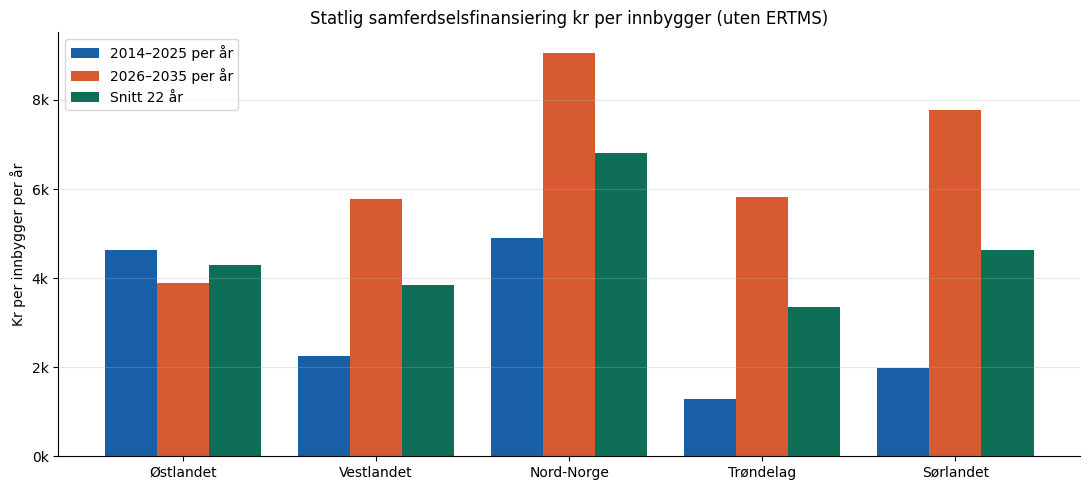

In [54]:
kr_innb_ferdig_aar = {r: agg.loc[REGION_NAVN[r], 'Ferdig'] * 1e6 / FOLK[r] / 12 for r in REGIONS}
kr_innb_bygges_aar = {r: agg.loc[REGION_NAVN[r], 'Bygges'] * 1e6 / FOLK[r] / 10 for r in REGIONS}
kr_innb_snitt = {r: agg.loc[REGION_NAVN[r], 'Total'] * 1e6 / FOLK[r] / 22 for r in REGIONS}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(REGIONS))
w = 0.27

ax.bar(x - w, [kr_innb_ferdig_aar[r] for r in REGIONS], w, label='2014–2025 per år', color='#185FA5')
ax.bar(x,     [kr_innb_bygges_aar[r] for r in REGIONS], w, label='2026–2035 per år', color='#D85A30')
ax.bar(x + w, [kr_innb_snitt[r]      for r in REGIONS], w, label='Snitt 22 år',      color='#0F6E56')

ax.set_xticks(x)
ax.set_xticklabels([REGION_NAVN[r] for r in REGIONS])
ax.set_ylabel('Kr per innbygger per år')
ax.set_title('Statlig samferdselsfinansiering kr per innbygger (uten ERTMS)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{int(v/1000)}k'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Plott 2: Andel av satsing vs befolkningsandel

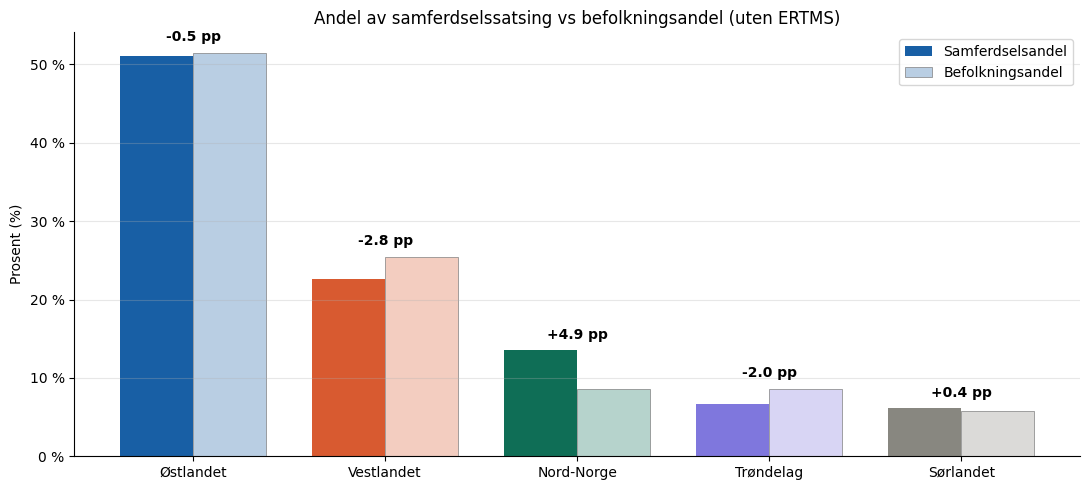

In [55]:
total_all = agg['Total'].sum()
samf_andel = {r: agg.loc[REGION_NAVN[r], 'Total'] / total_all * 100 for r in REGIONS}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(REGIONS))
w = 0.38

samf = [samf_andel[r] for r in REGIONS]
bef  = [BEF_ANDEL[r]  for r in REGIONS]
farger_samf = [FARGER[r] for r in REGIONS]
farger_bef  = [FARGER[r] + '4D' for r in REGIONS]  # 30 % alpha

ax.bar(x - w/2, samf, w, label='Samferdselsandel', color=farger_samf)
ax.bar(x + w/2, bef,  w, label='Befolkningsandel', color=farger_bef, edgecolor='gray', linewidth=0.5)

for i, (s, b) in enumerate(zip(samf, bef)):
    diff = s - b
    sign = '+' if diff >= 0 else ''
    ax.text(i, max(s, b) + 1.5, f'{sign}{diff:.1f} pp', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([REGION_NAVN[r] for r in REGIONS])
ax.set_ylabel('Prosent (%)')
ax.set_title('Andel av samferdselssatsing vs befolkningsandel (uten ERTMS)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f'{int(v)} %'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Plott 3: Trend per 3-årsperiode (stablet)

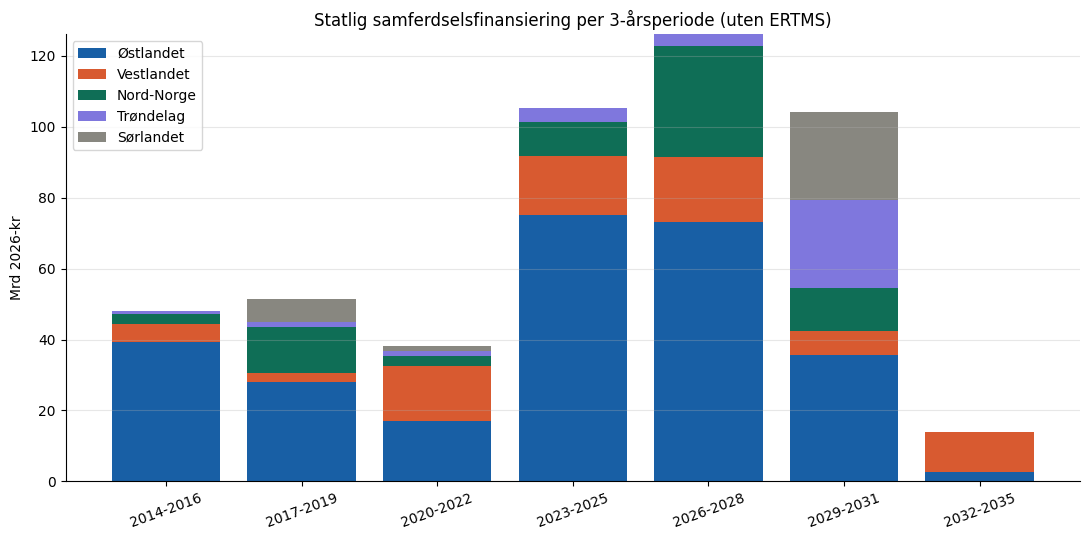


Vestlandets andel per periode:
  2014-2016:  10.7 %   (befolkning: 25.5 %)
  2017-2019:   4.7 %   (befolkning: 25.5 %)
  2020-2022:  41.1 %   (befolkning: 25.5 %)
  2023-2025:  15.7 %   (befolkning: 25.5 %)
  2026-2028:  14.5 %   (befolkning: 25.5 %)
  2029-2031:   6.5 %   (befolkning: 25.5 %)
  2032-2035:  80.7 %   (befolkning: 25.5 %)


In [56]:
perioder = [(2014,2016), (2017,2019), (2020,2022), (2023,2025),
            (2026,2028), (2029,2031), (2032,2035)]
periode_lbl = [f'{s}-{e}' for s,e in perioder]

data_periode = {}
for r in REGIONS:
    data_periode[r] = []
    for s, e in perioder:
        v = df[(df['landsdel']==r) & (df['aar_ferdig']>=s) & (df['aar_ferdig']<=e)]['stat_korrigert_2026'].sum()
        data_periode[r].append(v/1000)  # mrd

fig, ax = plt.subplots(figsize=(11, 5.5))
bottom = np.zeros(len(perioder))
for r in REGIONS:
    vals = data_periode[r]
    ax.bar(periode_lbl, vals, bottom=bottom, label=REGION_NAVN[r], color=FARGER[r])
    bottom += np.array(vals)

ax.set_ylabel('Mrd 2026-kr')
ax.set_title('Statlig samferdselsfinansiering per 3-årsperiode (uten ERTMS)')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Vis Vestlandets andel per periode
print('\nVestlandets andel per periode:')
for i, (s, e) in enumerate(perioder):
    total = sum(data_periode[r][i] for r in REGIONS)
    v_pct = data_periode['VEST'][i] / total * 100 if total > 0 else 0
    print(f'  {s}-{e}: {v_pct:5.1f} %   (befolkning: {BEF_ANDEL["VEST"]:.1f} %)')

## 6. Plott 4: Fordeling per virksomhet

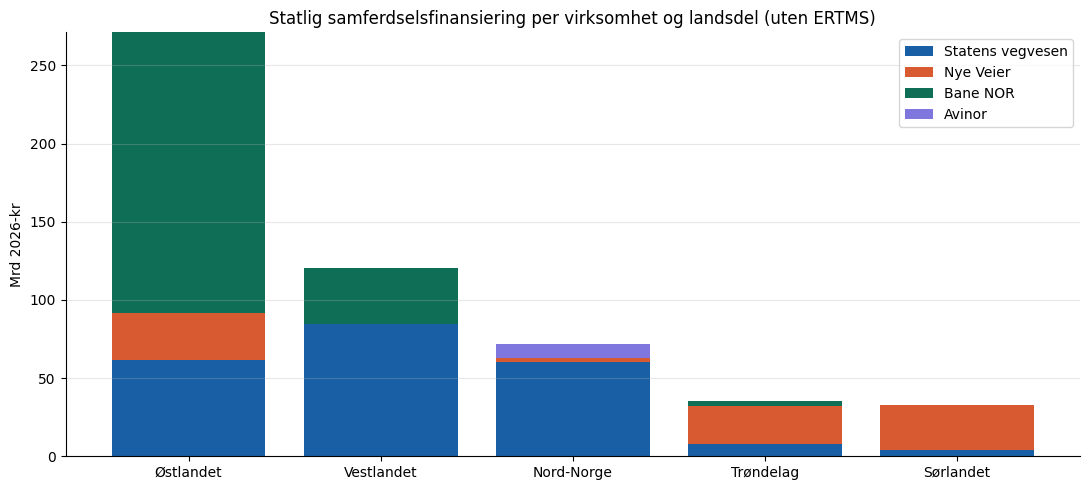

In [57]:
virk = df.groupby(['landsdel', 'virksomhet'])['stat_korrigert_2026'].sum().unstack(fill_value=0)
virk = virk.reindex(REGIONS).fillna(0)

# Sikre at alle virksomheter er med, i riktig rekkefølge
for c in ['SVV', 'NV', 'BANE', 'AVINOR']:
    if c not in virk.columns:
        virk[c] = 0
virk = virk[['SVV', 'NV', 'BANE', 'AVINOR']]

virk_farger = {'SVV': '#185FA5', 'NV': '#D85A30', 'BANE': '#0F6E56', 'AVINOR': '#7F77DD'}
virk_navn = {'SVV': 'Statens vegvesen', 'NV': 'Nye Veier', 'BANE': 'Bane NOR', 'AVINOR': 'Avinor'}

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(REGIONS))
for v in ['SVV', 'NV', 'BANE', 'AVINOR']:
    vals = virk[v].values / 1000
    ax.bar([REGION_NAVN[r] for r in REGIONS], vals, bottom=bottom,
           label=virk_navn[v], color=virk_farger[v])
    bottom += vals

ax.set_ylabel('Mrd 2026-kr')
ax.set_title('Statlig samferdselsfinansiering per virksomhet og landsdel (uten ERTMS)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Oppsummeringstabell

In [58]:
sammendrag = pd.DataFrame({
    'Befolkning': [FOLK[r] for r in REGIONS],
    'Bef.andel (%)': [BEF_ANDEL[r] for r in REGIONS],
    'Ferdig 2014–2025 (mrd)': [agg.loc[REGION_NAVN[r], 'Ferdig']/1000 for r in REGIONS],
    'Bygges 2026–2035 (mrd)': [agg.loc[REGION_NAVN[r], 'Bygges']/1000 for r in REGIONS],
    'Total (mrd)': [agg.loc[REGION_NAVN[r], 'Total']/1000 for r in REGIONS],
    'Samf.andel (%)': [samf_andel[r] for r in REGIONS],
    'Avvik (pp)': [samf_andel[r] - BEF_ANDEL[r] for r in REGIONS],
    'Kr/innb totalt': [agg.loc[REGION_NAVN[r], 'Total']*1e6/FOLK[r] for r in REGIONS],
}, index=[REGION_NAVN[r] for r in REGIONS])

sammendrag.round(1)

,Befolkning,Bef.andel (%),Ferdig 2014–2025 (mrd),Bygges 2026–2035 (mrd),Total (mrd),Samf.andel (%),Avvik (pp),Kr/innb totalt
Østlandet,2870000,51.5,159.6,111.6,271.2,51.0,-0.5,94488.1
Vestlandet,1420000,25.5,38.5,81.9,120.5,22.7,-2.8,84835.9
Nord-Norge,480000,8.6,28.3,43.5,71.8,13.5,4.9,149556.2
Trøndelag,480000,8.6,7.4,28.0,35.3,6.7,-2.0,73632.3
Sørlandet,320000,5.7,7.7,24.9,32.6,6.1,0.4,101756.2


In [59]:
svv = df[df['virksomhet'] == 'SVV']

svv_ferdig = svv[svv['aar_ferdig'] <= 2025]['stat_korrigert_2026'].sum()
svv_bygges  = svv[svv['aar_ferdig'] >= 2026]['stat_korrigert_2026'].sum()
svv_total   = svv['stat_korrigert_2026'].sum()

print("SVV — gjennomsnittlig statlig veifinansiering per år (2026-kr):")
print(f"  2014–2025 (12 år):  {svv_ferdig/12/1000:.1f} mrd/år  (totalt {svv_ferdig/1000:.1f} mrd)")
print(f"  2026–2035 (10 år):  {svv_bygges/10/1000:.1f} mrd/år  (totalt {svv_bygges/1000:.1f} mrd)")
print(f"  2014–2035 (22 år):  {svv_total/22/1000:.1f} mrd/år  (totalt {svv_total/1000:.1f} mrd)")


SVV — gjennomsnittlig statlig veifinansiering per år (2026-kr):
  2014–2025 (12 år):  9.2 mrd/år  (totalt 110.0 mrd)
  2026–2035 (10 år):  10.8 mrd/år  (totalt 107.8 mrd)
  2014–2035 (22 år):  9.9 mrd/år  (totalt 217.8 mrd)


In [ ]:
svv_vest = df[(df['virksomhet'] == 'SVV') & (df['landsdel'] == 'VEST')]

total = svv_vest['stat_korrigert_2026'].sum()
ferdig = svv_vest[svv_vest['aar_ferdig'] <= 2025]['stat_korrigert_2026'].sum()
bygges = svv_vest[svv_vest['aar_ferdig'] >= 2026]['stat_korrigert_2026'].sum()

print(f"SVV statlige midler til Vestlandet siden 2014 (2026-kr):")
print(f"  Ferdige prosjekter 2014–2025:  {ferdig/1000:.1f} mrd  ({ferdig/12/1000:.2f} mrd/år)")
print(f"  Under bygging (ferdig 2026+):  {bygges/1000:.1f} mrd  ({bygges/10/1000:.2f} mrd/år)")
print(f"  Totalt:                        {total/1000:.1f} mrd")
print()
print("Prosjekter:")
print(svv_vest[['navn', 'aar_ferdig', 'stat_korrigert_2026', 'status']]
      .sort_values('aar_ferdig')
      .rename(columns={'stat_korrigert_2026': 'mill_kr'})
      .assign(mill_kr=lambda x: x['mill_kr'].round(0).astype(int))
      .to_string(index=False))
